<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-20 04:21:54--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  59.1MB/s    in 3.5s    

2026-01-20 04:21:58 (57.1 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [19]:
!pip install seaborn

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
import seaborn as sns

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [9]:
## Write your code here
QUERY = """
SELECT CompTotal, COUNT(*) as count 
FROM main 
GROUP BY CompTotal 
ORDER BY CompTotal
"""
df_CompTotal = pd.read_sql_query(QUERY, conn)
print(df_CompTotal)

          CompTotal  count
0               NaN  31697
1      0.000000e+00    127
2      1.000000e+00     12
3      2.000000e+00      4
4      3.000000e+00      1
...             ...    ...
3333   8.000000e+27      1
3334   1.000000e+44      1
3335   1.000000e+53      1
3336   1.000000e+65      1
3337  1.000000e+150      1

[3338 rows x 2 columns]


In [30]:
# 1. Clean Data: Remove NaN and zero/negative for log scaling
df_clean = df_CompTotal.dropna(subset=['CompTotal'])
df_plot = df_clean[df_clean['CompTotal'] > 0].copy()

In [31]:
# 2. Filter Extreme Outliers: Realistically, comp rarely exceeds $100M (1e8)
# Adjust this threshold based on your specific dataset
df_plot = df_plot[df_plot['CompTotal'] < 1e9] 

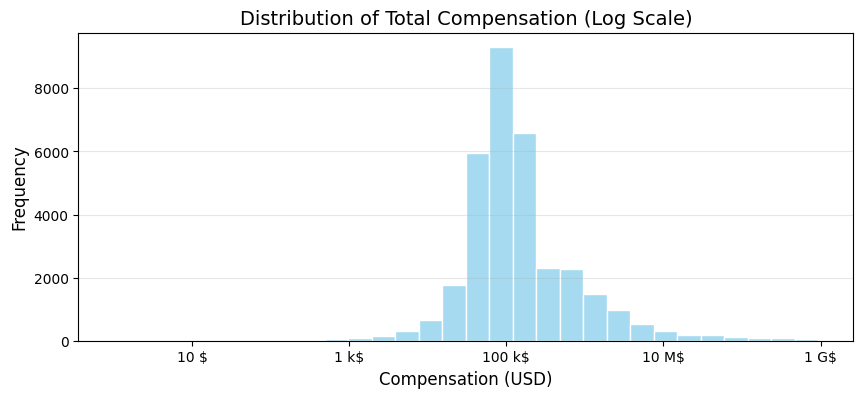

In [33]:
plt.figure(figsize=(10, 4))
ax = sns.histplot(
    data=df_plot, 
    x='CompTotal', 
    weights='count', 
    log_scale=True,  # Crucial for wide-ranging data
    bins=30, 
    color='skyblue',
    edgecolor='white'
)
# 3. Format X-axis to look like money instead of scientific notation
ax.xaxis.set_major_formatter(ticker.EngFormatter(unit='$'))
plt.title('Distribution of Total Compensation (Log Scale)', fontsize=14)
plt.xlabel('Compensation (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [38]:
## Write your code here
QUERY = """
SELECT YearsCodePro, COUNT(*) as count 
FROM main 
GROUP BY YearsCodePro
ORDER BY YearsCodePro
"""
df_YrCdPro = pd.read_sql_query(QUERY, conn)
#print(df_YrCdPro)

In [36]:
# 1. Map string/None values to numbers
# 'None' is converted to NaN, then dropped or replaced with 0
df_YrCdPro['YearsCodePro'] = pd.to_numeric(df_YrCdPro['YearsCodePro'], errors='coerce')

# 2. Drop NaN values for a clean professional distribution
df_clean = df_YrCdPro.dropna(subset=['YearsCodePro'])

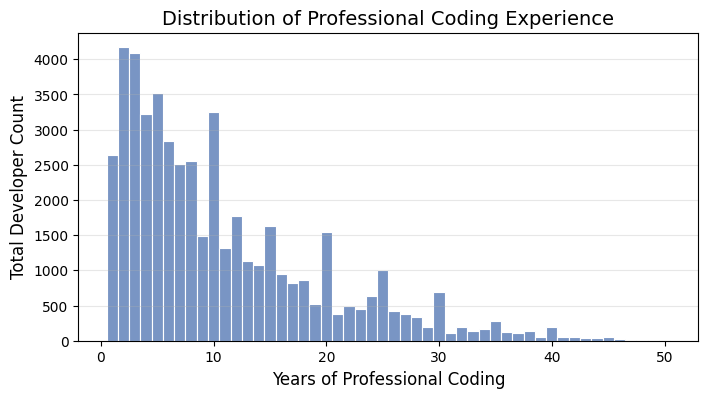

In [39]:
plt.figure(figsize=(8, 4))
# Use discrete=True for integer-based 'Years' data
ax = sns.histplot(
    data=df_clean, 
    x='YearsCodePro', 
    weights='count', 
    discrete=True, 
    color='#4c72b0',
    edgecolor='white'
)
# Refine labels and titles
plt.title('Distribution of Professional Coding Experience', fontsize=14)
plt.xlabel('Years of Professional Coding', fontsize=12)
plt.ylabel('Total Developer Count', fontsize=12)
# Optional: Add a grid for better readability
plt.grid(axis='y', alpha=0.3)
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [53]:
## Write your code here
QUERY = """
SELECT 
    CASE 
        WHEN Age < 25 THEN '<25'
        WHEN Age BETWEEN 25 AND 34 THEN '25-34'
        WHEN Age BETWEEN 35 AND 44 THEN '35-44'
        WHEN Age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55+' 
    END AS AgeGroup,
    CompTotal
FROM main
WHERE CompTotal IS NOT NULL 
  AND CompTotal > 0
  AND CompTotal < 1e9 

"""
df_Age_CT = pd.read_sql_query(QUERY, conn)
#print(df_Age_CT)

In [47]:
#df_Age_CT.head()

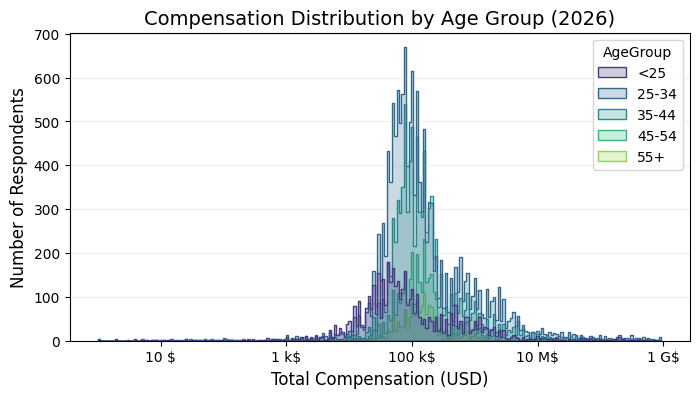

In [52]:
# 1. Setup the figure
plt.figure(figsize=(8, 4))
# 2. Create the histogram with log scale
# hue='AgeGroup' creates separate colors for each group
# element='step' or 'poly' makes overlaid histograms easier to see
ax = sns.histplot(
    data=df_Age_CT, 
    x='CompTotal', 
    hue='AgeGroup', 
    hue_order=['<25', '25-34', '35-44', '45-54', '55+'],
    log_scale=True, 
    element='step', 
    fill=True,
    palette='viridis'
)
# 3. Format the X-axis for currency (removes 'e' notation)
ax.xaxis.set_major_formatter(ticker.EngFormatter(unit='$'))
# 4. Final labels
plt.title('Compensation Distribution by Age Group (2026)', fontsize=14)
plt.xlabel('Total Compensation (USD)', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [54]:
## Write your code here
QUERY = """
SELECT 
    CASE 
        WHEN Age < 25 THEN '<25'
        WHEN Age BETWEEN 25 AND 34 THEN '25-34'
        WHEN Age BETWEEN 35 AND 44 THEN '35-44'
        WHEN Age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55+' 
    END AS AgeGroup,
    TimeSearching
FROM main
WHERE TimeSearching IS NOT NULL 
  AND Age IS NOT NULL
  AND TimeSearching < 300
"""
df_Age_TS = pd.read_sql_query(QUERY, conn)
print(df_Age_TS)

      AgeGroup        TimeSearching
0        35-44  30-60 minutes a day
1        35-44  30-60 minutes a day
2        25-34  15-30 minutes a day
3        35-44  15-30 minutes a day
4        35-44  30-60 minutes a day
...        ...                  ...
18751      <25  30-60 minutes a day
18752    45-54  30-60 minutes a day
18753      <25  30-60 minutes a day
18754    25-34  15-30 minutes a day
18755    35-44  15-30 minutes a day

[18756 rows x 2 columns]


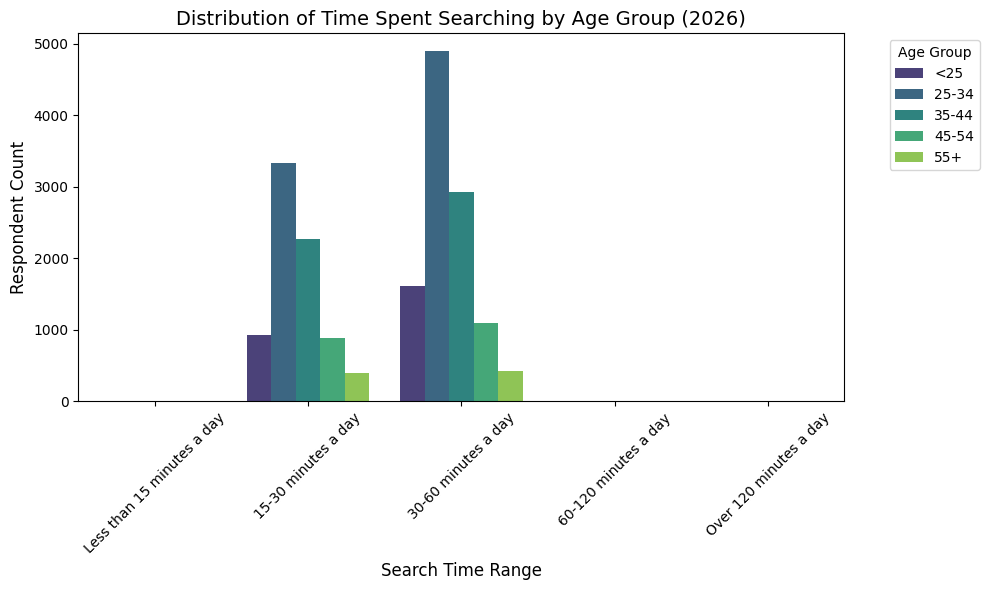

In [58]:
# 1. Define the logical order for your categories
time_order = [
    'Less than 15 minutes a day', 
    '15-30 minutes a day', 
    '30-60 minutes a day', 
    '60-120 minutes a day', 
    'Over 120 minutes a day'
]
age_order = ['<25', '25-34', '35-44', '45-54', '55+']
# 2. Plotting
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df_Age_TS, 
    x='TimeSearching', 
    hue='AgeGroup', 
    order=time_order, 
    hue_order=age_order,
    palette='viridis'
)
# 3. Aesthetics
plt.title('Distribution of Time Spent Searching by Age Group (2026)', fontsize=14)
plt.xlabel('Search Time Range', fontsize=12)
plt.ylabel('Respondent Count', fontsize=12)
plt.xticks(rotation=45) # Rotate labels for readability
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


In [ ]:
Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.

In [99]:
## Write your code here
QUERY = """
SELECT DatabaseWantToWorkWith, COUNT(*) AS Count
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
GROUP BY DatabaseWantToWorkWith
ORDER BY Count DESC
LIMIT 5;
"""
df_DB_WTW = pd.read_sql_query(QUERY, conn)
print(df_DB_WTW)

  DatabaseWantToWorkWith  Count
0             PostgreSQL   3738
1      PostgreSQL;SQLite   1533
2                 SQLite   1476
3   Microsoft SQL Server   1431
4                  MySQL   1139


In [100]:
df_DB_WTW['DatabaseWantToWorkWith'] = df_DB_WTW['DatabaseWantToWorkWith'].str.split(';')

In [101]:
df_DB_WTW_exploded = df_DB_WTW.explode('DatabaseWantToWorkWith')

In [102]:
df_DB_WTW_exploded.head()

,DatabaseWantToWorkWith,Count
0,PostgreSQL,3738
1,PostgreSQL,1533
1,SQLite,1533
2,SQLite,1476
3,Microsoft SQL Server,1431


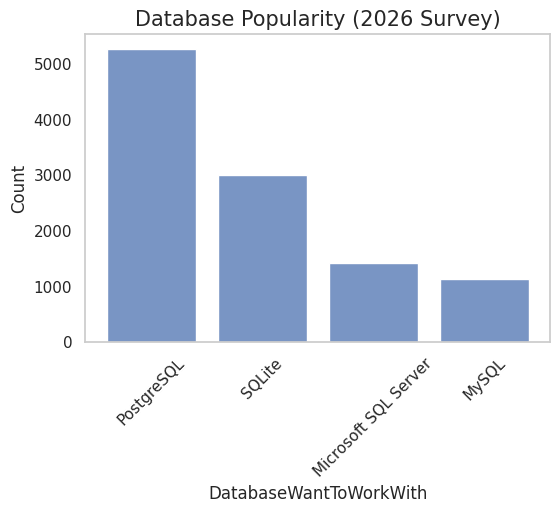

In [115]:
# Optional: Set a modern 2026 theme
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(6,4))
sns.histplot(data=df_DB_WTW_exploded, x='DatabaseWantToWorkWith', weights='Count', discrete=True, shrink=0.8)
plt.grid(False)
plt.title('Database Popularity (2026 Survey)', fontsize=15)

plt.xticks(rotation=45) # Rotate names if they overlap
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [126]:
## Write your code here
QUERY = """
SELECT RemoteWork, COUNT(*) AS Count
FROM main
GROUP BY RemoteWork
ORDER BY Count DESC
"""
df_RMWK = pd.read_sql_query(QUERY, conn)
#print(df_RMWK)

In [127]:
df_RMWK['RemoteWork'] = df_RMWK['RemoteWork'].replace('Hybrid (some remote, some in-person)','Hybrid')

In [128]:
df_RMWK.head()

,RemoteWork,Count
0,Hybrid,23015
1,Remote,20831
2,In-person,10960
3,None,10631


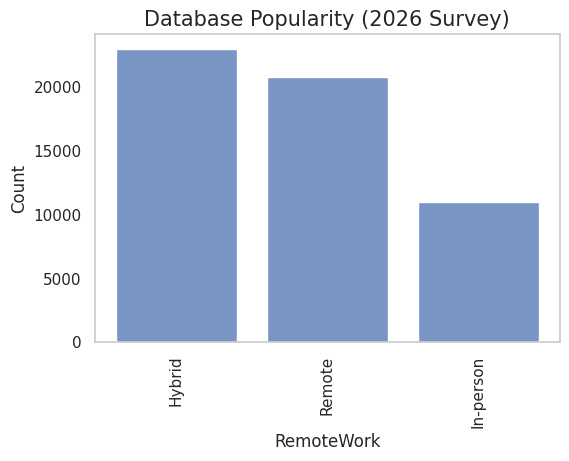

In [129]:
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(6,4))
sns.histplot(data=df_RMWK, x='RemoteWork', weights='Count', discrete=True, shrink=0.8)
plt.grid(False)
plt.title('Database Popularity (2026 Survey)', fontsize=15)

plt.xticks(rotation=90) # Rotate names if they overlap
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [147]:
## Write your code here
QUERY = """
   WITH RankedComp AS (
    SELECT 
        Age, 
        CompTotal,
        ROW_NUMBER() OVER (PARTITION BY Age ORDER BY CompTotal) as Row_Asc,
        COUNT(*) OVER (PARTITION BY Age) as Total_Count
    FROM main
    WHERE Age BETWEEN 45 AND 60 AND CompTotal IS NOT NULL
)
SELECT 
    Age, 
    AVG(CompTotal) as Median_Comp
FROM RankedComp
WHERE Row_Asc IN (FLOOR((Total_Count + 1) / 2.0), CEIL((Total_Count + 1) / 2.0))
GROUP BY Age
ORDER BY Age;

"""
df_Age_CT1 = pd.read_sql_query(QUERY, conn)
print(df_Age_CT1)

               Age  Median_Comp
0  45-54 years old     130000.0
1  55-64 years old     135000.0


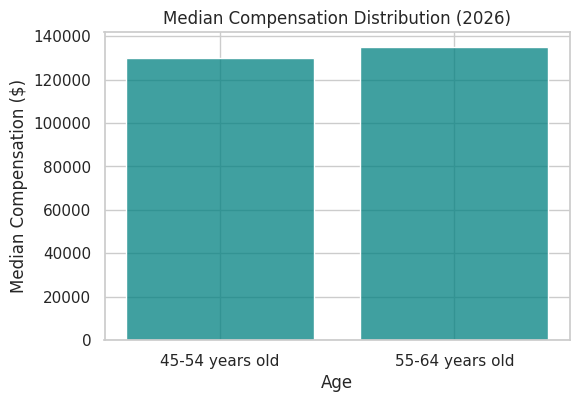

In [156]:
# Use weights to make bar height equal to the median value
plt.figure(figsize=(6,4))
sns.histplot(data= df_Age_CT1, x='Age', weights='Median_Comp', discrete=True, shrink=0.8, color='teal')

plt.title('Median Compensation Distribution (2026)')
plt.ylabel('Median Compensation ($)')
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [166]:
## Write your code here
QUERY = """
 SELECT 
    CAST(YearsCodePro AS FLOAT) AS Experience, 
    JobSat 
FROM main
WHERE YearsCodePro IS NOT NULL 
  AND JobSat IS NOT NULL;
"""
df_JobSat = pd.read_sql_query(QUERY, conn)
#print(df_JobSat)

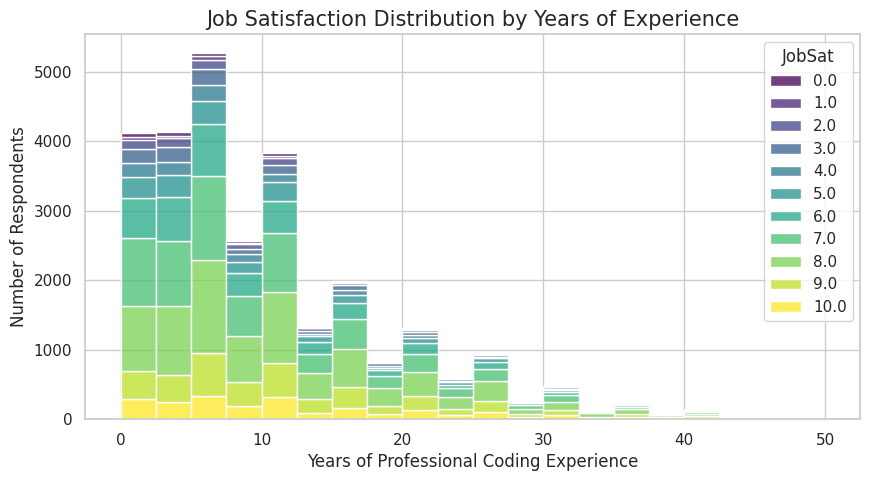

In [167]:
# Plotting the distribution
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
# hue='JobSat' colors the bins by satisfaction level
# multiple='stack' shows the composition within each experience bin
sns.histplot(
    data=df_JobSat, 
    x='Experience', 
    hue='JobSat', 
    multiple='stack', 
    bins=20, 
    palette='viridis'
)
plt.title('Job Satisfaction Distribution by Years of Experience', fontsize=15)
plt.xlabel('Years of Professional Coding Experience', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [168]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
